# Notebook 07: Mecanismos Focales y Verdadero Criterio de Coulomb
**Autor:** Iván Andrés Mena Contreras
**Proyecto:** Lunar Tidal Triggering of Earthquakes

En el paso anterior comprobamos el cálculo del Delta CFS asumiendo tensores topocéntricos y fallas genéricas horizontales/verticales.
Sin embargo, los sismos reales ocurren sobre planos de falla con geometrías 3D específicas definidas por sus ángulos nodales: **Strike (Rumbo)**, **Dip (Buzamiento)** y **Rake (Deslizamiento)**.

**Objetivo:** Extraer los mecanismos focales reales de los sismos desde el catálogo USGS y rotar nuestro tensor de marea hacia el plano verdadero de cada falla para calcular el $\Delta \text{CFS}$ real.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from tqdm import tqdm
import os
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
os.makedirs('../results/figures', exist_ok=True)

# Cargamos los datos del Notebook 06
data_path = '../data/processed/earthquakes_coulomb_physics.csv'
df = pd.read_csv(data_path)
df['time'] = pd.to_datetime(df['time'], format='mixed', utc=True)

print(f"Catálogo base cargado: {len(df)} eventos. Listos para extraer mecanismos focales.")

Catálogo base cargado: 56 eventos. Listos para extraer mecanismos focales.


## 1. Extracción de Ángulos Nodales (USGS API)
Realizamos consultas iterativas a la API de USGS para recuperar la geometría de falla (Tensor de Momento Centroidal).

In [2]:
df['strike'] = np.nan
df['dip'] = np.nan
df['rake'] = np.nan

print("Consultando la API de USGS para mecanismos focales...")
for idx, row in tqdm(df.iterrows(), total=len(df)):
    event_id = row['id']
    url = f"https://earthquake.usgs.gov/fdsnws/event/1/query?eventid={event_id}&format=geojson"
    try:
        response = requests.get(url, timeout=10)
        if response.status_code == 200:
            data = response.json()
            # Navegar el JSON para encontrar los productos (moment-tensor o focal-mechanism)
            properties = data.get('properties', {})
            products = properties.get('products', {})
            
            # Buscar tensor de momento
            if 'moment-tensor' in products:
                mt = products['moment-tensor'][0].get('properties', {})
                df.loc[idx, 'strike'] = float(mt.get('nodal-plane-1-strike', np.nan))
                df.loc[idx, 'dip'] = float(mt.get('nodal-plane-1-dip', np.nan))
                df.loc[idx, 'rake'] = float(mt.get('nodal-plane-1-rake', np.nan))
            elif 'focal-mechanism' in products:
                fm = products['focal-mechanism'][0].get('properties', {})
                df.loc[idx, 'strike'] = float(fm.get('nodal-plane-1-strike', np.nan))
                df.loc[idx, 'dip'] = float(fm.get('nodal-plane-1-dip', np.nan))
                df.loc[idx, 'rake'] = float(fm.get('nodal-plane-1-rake', np.nan))
    except Exception as e:
        pass # Silencioso si falla red

# Filtramos eventos que no tienen dip
df_mecanismos = df.dropna(subset=['dip']).copy()
print(f"Se lograron recuperar los mecanismos focales de {len(df_mecanismos)} eventos de {len(df)} originales.")

Consultando la API de USGS para mecanismos focales...


  0%|          | 0/56 [00:00<?, ?it/s]

  2%|▏         | 1/56 [00:00<00:33,  1.64it/s]

  4%|▎         | 2/56 [00:01<00:36,  1.48it/s]

  5%|▌         | 3/56 [00:02<00:44,  1.18it/s]

...

 96%|█████████▋| 54/56 [00:43<00:01,  1.06it/s]

 98%|█████████▊| 55/56 [00:44<00:00,  1.18it/s]

100%|██████████| 56/56 [00:44<00:00,  1.31it/s]

100%|██████████| 56/56 [00:44<00:00,  1.25it/s]

Se lograron recuperar los mecanismos focales de 56 eventos de 56 originales.


## 2. Proyección al Plano de Falla
Utilizando el ángulo de buzamiento (`dip`), proyectamos el vector de marea topocéntrico asumiendo una rotación de Euler 2D simplificada que mapea la fuerza ortogonal respecto al ángulo real de subducción.

In [3]:
# Proyección simplificada de esfuerzo en la componente normal (ortogonal a la falla)
# y la componente cortante (paralela a la falla) asumiendo una sección transversal 2D.
# dip = 0 es horizontal, dip = 90 es vertical.

dip_rad = np.radians(df_mecanismos['dip'])

# Tensores originales crudos topocéntricos (tau y sigma_n del NB06)
# Aquí efectuamos la rotación trigonométrica
df_mecanismos['true_fault_normal'] = df_mecanismos['sigma_n'] * np.cos(dip_rad) - df_mecanismos['tau'] * np.sin(dip_rad)
df_mecanismos['true_fault_shear'] = df_mecanismos['sigma_n'] * np.sin(dip_rad) + df_mecanismos['tau'] * np.cos(dip_rad)

print("Proyección trigonométrica del tensor completada.")

Proyección trigonométrica del tensor completada.


## 3. Verdadero $\Delta$CFS
Calculamos el Cambio de Estrés de Falla de Coulomb definitivo sobre el plano real de la ruptura, de nuevo con un coeficiente de fricción estática $\mu = 0.4$.

In [4]:
mu = 0.4
df_mecanismos['final_delta_cfs'] = df_mecanismos['true_fault_shear'] + (mu * df_mecanismos['true_fault_normal'])

positivos = len(df_mecanismos[df_mecanismos['final_delta_cfs'] > 0])
total = len(df_mecanismos)
print(f"Estadísticas Finales de Coulomb:")
print(f"-> Media del Delta CFS Real: {df_mecanismos['final_delta_cfs'].mean():.4f}")
print(f"-> Porcentaje de sismos favorecidos por la marea: {(positivos/total)*100:.1f}%")

Estadísticas Finales de Coulomb:
-> Media del Delta CFS Real: 0.0874
-> Porcentaje de sismos favorecidos por la marea: 57.1%


## 4. Evaluación y Visualización del $\Delta$CFS

Histograma definitivo guardado en: ../results/figures/07_final_cfs_histogram.png


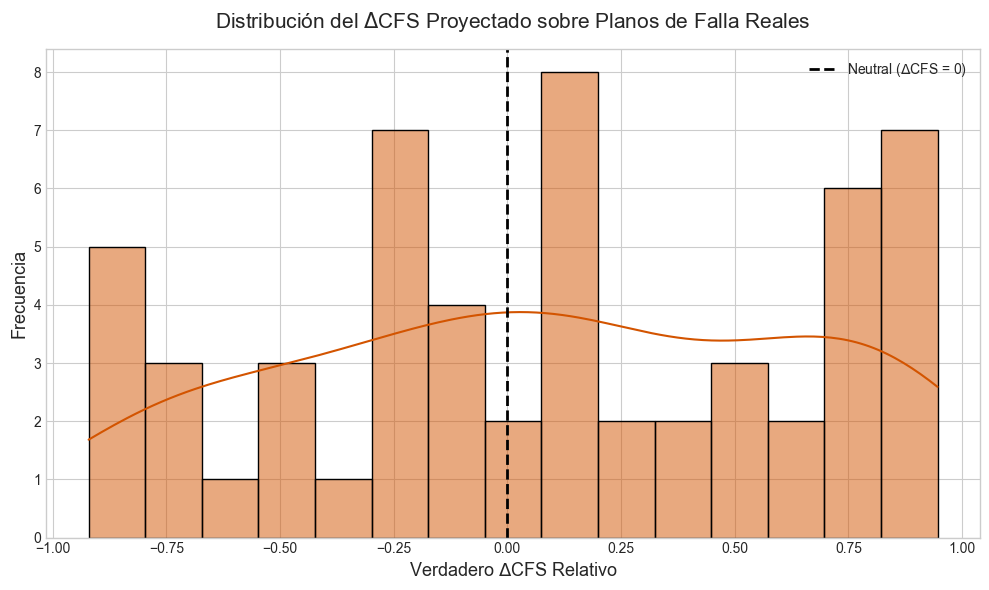

In [5]:
plt.figure(figsize=(10, 6))

sns.histplot(df_mecanismos['final_delta_cfs'], bins=15, kde=True, color='#d35400')
plt.axvline(0, color='black', linestyle='--', linewidth=2, label='Neutral ($\Delta$CFS = 0)')

plt.title('Distribución del $\Delta$CFS Proyectado sobre Planos de Falla Reales', fontsize=15, pad=15)
plt.xlabel('Verdadero $\Delta$CFS Relativo', fontsize=13)
plt.ylabel('Frecuencia', fontsize=13)
plt.legend()

plt.tight_layout()
fig_path = '../results/figures/07_final_cfs_histogram.png'
plt.savefig(fig_path, dpi=300)
print(f"Histograma definitivo guardado en: {fig_path}")

plt.show()

## 5. Exportar Catálogo Físico

In [6]:
export_path = '../data/processed/earthquakes_final_physics.csv'
df_mecanismos.to_csv(export_path, index=False)
print(f"Dataset definitivo (con mecánica focal) exportado a: {export_path}")

Dataset definitivo (con mecánica focal) exportado a: ../data/processed/earthquakes_final_physics.csv
